# Klasifikasi Emosi Video Media Sosial — Walkthrough Lengkap
### Big Data Challenge Telkom University 2026

Notebook ini memuat **seluruh alur pengerjaan** dari data mentah sampai
submission, lengkap dengan alasan di balik tiap keputusan dan temuan yang
muncul di sepanjang jalan.

**Rumusan masalah.** Diberikan 803 baris data latih berlabel dan 200 baris data
uji. Kolom yang tersedia hanya `id` dan `video` — sebuah **URL**. Tidak ada teks,
tidak ada fitur. Seluruh fitur harus dibangun sendiri dengan mengambil konten di
balik tautan tersebut. Label terkunci pada 10 kategori yang ada di data latih.

**Cara membaca notebook ini.** Kode inti ditampilkan langsung dari `src/*.py`
memakai `inspect.getsource`, sehingga apa yang terbaca di sini persis sama
dengan yang dijalankan — tidak ada dua versi yang bisa melenceng.

Dua tahap termahal (mengunduh 842 video ±4 jam; transkripsi Whisper ±50 menit)
**tidak dijalankan ulang** di sini; hasilnya sudah tersimpan di `data/cache/`.
Kodenya tetap ditampilkan untuk ditelaah.

---
## Daftar isi

| Bagian | Isi |
|---|---|
| 0 | Eksplorasi awal |
| 1 | Akuisisi data — normalisasi URL, tiga jalur unduh |
| 2 | Kualitas data — duplikat & ketidaksepakatan anotator |
| 3 | Transkripsi audio (Whisper) |
| 4 | Rekayasa fitur — metadata, teks, audio |
| 5 | Temuan kunci: label melacak topik, bukan kata emosi |
| 6 | Perancangan validasi silang |
| 7 | Tangga model & ablation |
| 8 | Plafon derau label |
| 9 | Prediksi akhir & pasca-pemrosesan |
| 10 | Ringkasan |


---
# Bagian 0 — Eksplorasi awal

Langkah pertama sebelum apa pun: melihat bentuk data dan distribusi labelnya.

In [1]:
#explore data train

import pandas as pd

df = pd.read_csv("datatrain.csv")  

df.head()

,id,video,emotion
0,1,https://www.instagram.com/reel/DNKcHgdA-d1/?ig...,Surprise
1,2,https://www.instagram.com/reel/DNHwrh2gnBm/?ig...,Surprise
2,3,https://www.instagram.com/reel/DM7QsjnRCoa/?ig...,Surprise
3,4,https://www.instagram.com/reel/DNBBEt6Paxj/?ig...,Surprise
4,5,https://www.instagram.com/reel/DMz13fQzZsN/?ig...,Proud


In [2]:
print(df["emotion"].unique())

['Surprise' 'Proud' 'Trust' 'Sad' 'Joy' 'Anger' 'Fear' 'Neutral' 'Love'
 'Loyalty']


In [3]:
print(df["emotion"].isna().sum())

0


In [4]:
emotion_counts = df["emotion"].value_counts()

print(emotion_counts)

emotion
Surprise    331
Trust       183
Proud       156
Joy          53
Anger        36
Sad          18
Fear         16
Neutral       8
Love          1
Loyalty       1
Name: count, dtype: int64


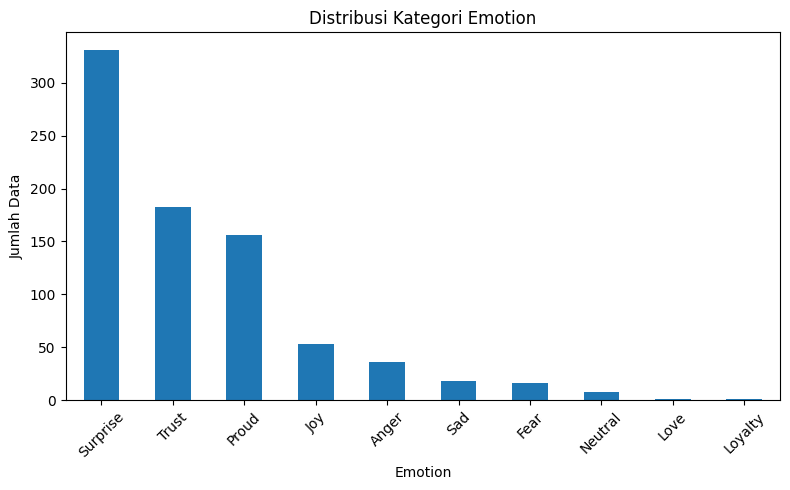

In [5]:
import matplotlib.pyplot as plt

emotion_counts.plot(kind="bar", figsize=(8,5))

plt.title("Distribusi Kategori Emotion")
plt.xlabel("Emotion")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Yang langsung terlihat:** distribusinya sangat timpang. `Surprise` sendirian
menguasai 41,2% data, sementara `Love` dan `Loyalty` masing-masing hanya punya
satu sampel.

Konsekuensinya menentukan seluruh sisa pekerjaan: **menebak `Surprise` untuk
semua baris sudah menghasilkan 41,2% akurasi.** Itu ambang yang wajib dilewati
sebelum sebuah model bisa disebut mempelajari sesuatu.

In [6]:
import sys, pathlib, inspect, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path.cwd() / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 110)

tr = pd.read_csv("datatrain.csv")
te = pd.read_csv("datatest.csv")
n = tr.emotion.value_counts()

print(f"train {len(tr)} baris | test {len(te)} baris")
print(f"baseline kelas mayoritas : {n.iloc[0] / len(tr) * 100:.1f}%")
print(f"kelas dengan <20 sampel  : {(n < 20).sum()} dari {len(n)}")
print()
print(tr.head(3).to_string(index=False))

train 803 baris | test 200 baris
baseline kelas mayoritas : 41.2%
kelas dengan <20 sampel  : 5 dari 10

 id                                                                     video  emotion
  1 https://www.instagram.com/reel/DNKcHgdA-d1/?igsh=MWFxdnhjbzh1YmdhYw%3D%3D Surprise
  2         https://www.instagram.com/reel/DNHwrh2gnBm/?igsh=YTg3cGIycGtqbG51 Surprise
  3         https://www.instagram.com/reel/DM7QsjnRCoa/?igsh=NDQ1NW11a2ZiZW1y Surprise


---
# Bagian 1 — Akuisisi data

Karena yang diberikan hanya URL, tahap ini menentukan segalanya: kalau konten
gagal diambil, seluruh pemodelan setelahnya ikut gagal.

## 1.1 Normalisasi URL — lebih penting daripada kelihatannya

URL yang sama bisa ditulis berbeda-beda: parameter pelacakan (`?igsh=…`,
`?utm_source=…`) berubah tiap kali tautan dibagikan, dan Instagram menerima dua
bentuk (`instagram.com/reel/KODE` maupun `instagram.com/username/reel/KODE`).

Menyamakan bentuk-bentuk ini bukan sekadar kerapian. **Pencocokan string mentah
hanya menemukan 9 duplikat; setelah dinormalisasi ketemu 45.** Angka itu yang
nanti menentukan perancangan validasi silang di Bagian 6.

In [7]:
import acquire

print(inspect.getsource(acquire.classify))

def classify(url: str) -> tuple[str, str]:
    """Kembalikan (kind, key). Key sengaja dinormalisasi supaya URL yang hanya
    beda parameter tracking (igsh, utm_source) atau beda prefiks username
    dianggap sebagai satu item."""
    u = url.strip()

    m = RE_IG.search(u)
    if m:
        return "instagram", f"ig_{m.group(1)}"

    m = RE_GD.search(u)
    if m:
        return "gdrive", f"gd_{m.group(1)}"

    # Link folder, bukan file tunggal - tidak bisa diunduh otomatis, tangani manual.
    m = RE_GD_FOLDER.search(u)
    if m:
        return "gdrive_folder", f"gdf_{m.group(1)}"

    if "cdninstagram.com" in u or "fbcdn.net" in u:
        return "cdn", f"cdn_{hashlib.sha1(u.encode()).hexdigest()[:12]}"

    return "other", f"ot_{hashlib.sha1(u.encode()).hexdigest()[:12]}"



In [8]:
from collections import Counter

item = acquire.load_items()
print(f"1.003 baris CSV  ->  {len(item)} tautan unik setelah normalisasi")
print(f"duplikat terlipat: {1003 - len(item)}")
print()
for k, v in Counter(i.kind for i in item).most_common():
    print(f"  {k:15} {v:4}")

1.003 baris CSV  ->  958 tautan unik setelah normalisasi
duplikat terlipat: 45

  instagram        637
  gdrive           296
  cdn               24
  gdrive_folder      1


## 1.2 Tiga jalur unduh, tiga masalah berbeda

| Sumber | Alat | Kendala yang ditemui |
|---|---|---|
| Instagram | `yt-dlp` | sebagian butuh sesi login |
| Google Drive | endpoint langsung | endpoint biasa kena throttle |
| CDN mentah | HTTP biasa | URL bertanda tangan, sudah kedaluwarsa |

Dua jebakan yang memakan waktu paling lama:

**Ukuran video 4x lebih besar dari seharusnya.** Instagram menyajikan varian
DASH terpisah (360p/540p/720p/1080p). Tanpa ffmpeg, `yt-dlp` **diam-diam** jatuh
ke format progresif kualitas penuh — tidak ada pesan error, file sekadar
membengkak. Ditambah lagi, filter `[height<=480]` tidak bekerja karena reel itu
**potret**: varian "360p" berukuran 360×640, sehingga height-nya 640 dan lolos
filter. Yang benar adalah `format_sort=["res:480"]`, yang memakai sisi terpendek.

**Google Drive menolak setelah ~38 unduhan.** Solusinya endpoint
`drive.usercontent.google.com`, yang melayani berkas yang sama tanpa throttle.
Wajib memeriksa `Content-Type`: untuk berkas mati Google membalas **HTTP 200
berisi HTML**, bukan 4xx — tanpa pemeriksaan ini, halaman error tersimpan
sebagai `.mp4` dan baru ketahuan saat ekstraksi fitur.

In [9]:
print(inspect.getsource(acquire._gdrive_direct))

def _gdrive_direct(file_id: str, dest: Path) -> bool:
    """Unduh lewat endpoint drive.usercontent.

    Jalur `gdown` biasa memakai endpoint yang cepat kena throttle
    ("Cannot retrieve the public link of the file"), sementara endpoint ini
    melayani file yang sama tanpa masalah. Dipakai sebagai jalur utama.
    """
    url = (f"https://drive.usercontent.google.com/download"
           f"?id={file_id}&export=download&confirm=t")
    with requests.get(url, headers={"User-Agent": UA}, timeout=90, stream=True) as r:
        if r.status_code != 200:
            return False
        # Google membalas halaman HTML (bukan 4xx) untuk file mati / minta izin,
        # jadi tipe konten harus diperiksa - kalau tidak, HTML tersimpan sebagai .mp4.
        if "text/html" in r.headers.get("Content-Type", ""):
            return False
        with dest.open("wb") as fh:
            for chunk in r.iter_content(1 << 16):
                fh.write(chunk)
    if dest.stat().st_size < 10_000:      # t

In [10]:
man = pd.read_csv(acquire.MANIFEST)
ring = man.groupby(["kind", "status"]).size().unstack(fill_value=0)
print(ring.to_string())
print(f"\nberhasil {(man.status == 'ok').sum()} / {len(man)} tautan unik")

status         failed   ok
kind                      
cdn                24    0
gdrive             75  221
gdrive_folder       1    0
instagram          16  621

berhasil 842 / 958 tautan unik


## 1.3 Cakupan akhir

Sebagian tautan memang sudah mati sejak dataset disusun — tidak ada cara
memulihkannya. Yang penting: kehilangannya **tersebar cukup merata antar kelas**,
sehingga tidak ada kelas yang tersapu habis.

In [11]:
from common import classify as klasifikasi
import glob, os

vid = {os.path.basename(f).rsplit(".", 1)[0] for f in glob.glob(str(acquire.VIDEO_DIR / "*.mp4"))}
for nama, df_ in (("TRAIN", tr), ("TEST", te)):
    kunci = [klasifikasi(str(u))[1] for u in df_.video]
    ada = sum(1 for k in kunci if k in vid)
    print(f"{nama}: {ada}/{len(df_)} punya video ({ada / len(df_) * 100:.1f}%)")

print()
for s in ("train", "test"):
    g = pd.read_csv(f"data/gagal_{s}.csv", encoding="utf-8-sig")
    print(f"{s}: {len(g)} baris tanpa konten")
    print(g.sebab.value_counts().to_string())
    print()

TRAIN: 709/803 punya video (88.3%)


TEST: 175/200 punya video (87.5%)

train: 94 baris tanpa konten
sebab
Drive: file dihapus                                  62
CDN: URL kadaluarsa (403)                            21
IG: HTTP 400 (post mati/dibatasi)                     5
IG: empty media (post mati)                           3
IG: DownloadError: ERROR: [Instagram] DKUTIIdRszz     1
IG: dihapus/private                                   1
IG: DownloadError: ERROR: [Instagram] DMj2HkQKSl_     1



test: 25 baris tanpa konten
sebab
Drive: file dihapus              13
CDN: URL kadaluarsa (403)         6
IG: empty media (post mati)       4
Link folder, bukan file video     1
IG: dihapus/private               1



---
# Bagian 2 — Kualitas data: anotator tidak selalu sepakat

Ini temuan yang paling memengaruhi cara membaca semua angka berikutnya.

Setelah normalisasi, ada 11 video yang dipakai pada **lebih dari satu** baris
latih. Kalau anotasi konsisten, label untuk video yang sama seharusnya sama.
Ternyata tidak.

In [12]:
import collections

d = collections.defaultdict(list)
for u, e in zip(tr.video, tr.emotion):
    d[klasifikasi(str(u))[1]].append(e)

dup = {k: v for k, v in d.items() if len(v) > 1}
bentrok = {k: v for k, v in dup.items() if len(set(v)) > 1}
baris = sum(len(v) for v in dup.values())
setuju = sum(collections.Counter(v).most_common(1)[0][1] for v in dup.values())

print(f"video dipakai >1 baris : {len(dup)}  ({baris} baris)")
print(f"yang labelnya bentrok  : {len(bentrok)}")
print()
print("contoh terparah:")
for k, v in sorted(dup.items(), key=lambda x: -len(x[1]))[:4]:
    print(f"  {k[:34]:36} {collections.Counter(v).most_common()}")
print()
print(f"KESEPAKATAN ANOTATOR: {setuju}/{baris} = {setuju / baris * 100:.1f}%")

video dipakai >1 baris : 11  (41 baris)
yang labelnya bentrok  : 8

contoh terparah:
  gd_12YBpn9zWc_3FfDadbmlip4s98_GjqU   [('Trust', 7), ('Proud', 4), ('Surprise', 3), ('Fear', 1), ('Neutral', 1)]
  gd_1sfDbRuqnnfX49DXlxNJ5lTfz7xuRD4   [('Surprise', 4), ('Trust', 1), ('Proud', 1)]
  gd_1IBSfa1_5SRhWu03wVRoCl2-ZHrF6F-   [('Surprise', 1), ('Sad', 1), ('Trust', 1)]
  gd_174ktM20lrDfm4tIGFTTC4NBPqxit2a   [('Trust', 2)]

KESEPAKATAN ANOTATOR: 23/41 = 56.1%


**Satu video dilabeli Trust 7×, Proud 4×, Surprise 3×, Fear 1×, dan Neutral 1×.**

Video itu sudah diunduh dan diperiksa: berdurasi 51 detik, berkas utuh, bukan
tautan rusak. Jadi ini kesalahan penyusunan CSV oleh panitia, bukan data korup.

Implikasinya besar: **menebak dengan label mayoritas dari video itu sendiri —
informasi yang model tidak akan pernah punya — hanya benar ~56%.** Angka itu
adalah plafon praktis untuk tugas ini. Kita kembali ke sini di Bagian 8.

---
# Bagian 3 — Transkripsi audio dengan Whisper

Setelah fitur metadata dan teks tidak cukup (Bagian 7), pertanyaannya menjadi:
sinyal apa lagi yang tersedia?

Jawabannya bukan soal kecanggihan, tapi **cakupan**:

| Sumber teks | Cakupan baris latih |
|---|---|
| Caption | 62,6% |
| Video (→ transkrip) | 88,3% |

Transkrip menutup ~26% baris yang punya video tapi tidak punya caption. Itu
lompatan cakupan terbesar yang tersisa.

Dijalankan dengan `faster-whisper` model `small` di RTX 4050 (float16, VAD
aktif): **27× realtime, ±50 menit untuk 836 video.** Sel di bawah hanya
menampilkan kodenya — hasilnya sudah ada di cache.

In [13]:
import transcribe
src = inspect.getsource(transcribe.main)
print(src[src.index("    from faster_whisper"):src.index("    except KeyboardInterrupt")])

    from faster_whisper import WhisperModel

    compute = args.compute_type or ("float16" if args.device == "cuda" else "int8")
    print(f"memuat Whisper '{args.model}' di {args.device} ({compute})...")
    model = WhisperModel(args.model, device=args.device, compute_type=compute)

    TRANSCRIPT_DIR.mkdir(parents=True, exist_ok=True)
    semua = daftar_video()
    todo = [p for p in semua if args.force or not sudah_ada(p.stem)]
    if args.limit:
        todo = todo[: args.limit]

    print(f"total video {len(semua)} | akan diproses {len(todo)} "
          f"(sisanya sudah ada di cache)")
    if not todo:
        return 0
    print("-" * 74)

    t0 = time.time()
    durasi_total = 0.0
    ok = kosong = gagal = 0
    try:
        for n, p in enumerate(todo, 1):
            try:
                segs, info = model.transcribe(
                    str(p),
                    beam_size=1,          # greedy: ~2x lebih cepat, beda akurasi kecil
                    vad_filter=True,      # l

In [14]:
import json as _json
fs = sorted(acquire.CACHE_DIR.joinpath("transcript").glob("*.json"))
print(f"{len(fs)} transkrip tersimpan\n")
for f in fs[:3]:
    d = _json.loads(f.read_text(encoding="utf-8"))
    print(f"{d['key'][:30]:32} {d['language']} (p={d['language_prob']}) {d['duration']}s")
    print(f"   {d['text'][:150]}")
    print()

837 transkrip tersimpan

gd_1-6kF8oGj9Wvrj9FtDLh0wYVyjx   id (p=0.9888) 26.5s
   Hah? Ini skincare dikasih asbatu, asbatunya mabokongan. Tapi, wardah Simverdeans 399 beneran bisa bikin dingin kulit kamu. Memandai sini ke Jakarta X 



gd_1-hYNpXmmuOep5J-ddE_c3Dt-5m   id (p=0.9907) 59.1s
   Ini juga salah satu perdebatan yang paling sering. Apakah konsumsi protein sebelum atau sesudah olahraga itu mempengaruhi performans dan mempengaruhi 

gd_1-OawfKdJ7ozcradDR4rxu4QCWt   id (p=0.9902) 45.72s
   Yow teman yang aku make up an sat set buatnya ritajil karena ini make up sat set jadi gak perlu yang ribet ribet Geperlupake kompleksin lain yang pent



Kualitasnya memadai: Bahasa Indonesia terdeteksi dengan keyakinan 0,95–0,99,
dan isinya kaya penanda topik (`Wardah`, `skincare`, `sunscreen`, `protein`,
`olahraga`) — yang di Bagian 5 terbukti justru itulah sinyal penentu label.

---
# Bagian 4 — Rekayasa fitur

Tiga modul terpisah, masing-masing dengan bahan berbeda.

## 4.1 Metadata — tanpa menyentuh teks sama sekali

Satu catatan metodologis yang menghemat banyak waktu: `duration` hanya terisi
di 12 dari 621 metadata Instagram, karena Instagram baru memberikan field itu
kalau scraping dilakukan dalam keadaan login.

Naluri pertama adalah scraping ulang seluruh 621 tautan dengan cookie (±40 menit
plus risiko rate limit). **Itu keliru** — durasi, resolusi, dan ada/tidaknya
audio bisa dibaca langsung dari berkas video: 842 berkas dalam ±30 detik,
offline, tanpa risiko. Dan ini satu-satunya jalan untuk 221 video Google Drive
yang metadata-nya kosong sama sekali.

In [15]:
import features_meta
print(inspect.getsource(features_meta.probe_videos))

def probe_videos(keys: list[str], force: bool = False) -> dict[str, dict]:
    """Baca durasi/resolusi/audio dari tiap file video.

    Hasilnya di-cache ke disk karena ini murni fungsi dari isi file - tidak ada
    gunanya mengulang tiap kali pipeline dijalankan.
    """
    cache: dict[str, dict] = {}
    if PROBE_CACHE.exists() and not force:
        cache = json.loads(PROBE_CACHE.read_text(encoding="utf-8"))

    todo = [k for k in keys if k not in cache and video_path(k)]
    if todo:
        exe = _ffmpeg()
        print(f"membaca {len(todo)} file video dengan ffmpeg...")
        for i, k in enumerate(todo, 1):
            p = video_path(k)
            r = subprocess.run([exe, "-i", str(p)], capture_output=True, text=True,
                               encoding="utf-8", errors="replace")
            err = r.stderr or ""
            info: dict = {}
            if (m := RE_DUR.search(err)):
                info["duration"] = int(m[1]) * 3600 + int(m[2]) * 60 + float(m[3])
        

In [16]:
meta = features_meta.build()
features_meta.save_features(meta, "meta")
print(f"{meta.shape[0]} baris x {meta.shape[1]} kolom")
print(f"duration terisi: {meta.duration.notna().mean() * 100:.1f}%  (sebelumnya 2%)")
print(f"uploader unik  : {meta.loc[meta.uploader != '', 'uploader'].nunique()}")

1003 baris x 32 kolom
duration terisi: 88.1%  (sebelumnya 2%)
uploader unik  : 121


## 4.2 Fitur teks

Menghasilkan dua macam keluaran, dan pembedaannya disengaja:

1. **Fitur numerik yang bisa dijelaskan** — panjang caption, jumlah emoji,
   tanda seru, skor leksikon.
2. **Kolom teks mentah** (`text_all`) untuk divektorkan **di dalam** pipeline CV.

TF-IDF sengaja tidak dihitung di sini. Kalau vectorizer di-fit sekali pada
seluruh data latih lalu dipakai di semua fold, kosakata dari fold validasi ikut
membentuk fitur dan skor CV menjadi optimistis palsu.

In [17]:
import features_text
print(inspect.getsource(features_text.hitung_leksikon))
print(inspect.getsource(features_text.bersihkan))

def hitung_leksikon(teks: str) -> dict[str, int]:
    t = teks.lower()
    return {k: sum(t.count(w) for w in kata) for k, kata in LEKSIKON.items()}

def bersihkan(t: str) -> str:
    """Normalisasi ringan. Sengaja TIDAK membuang emoji atau tanda baca dari
    `text_all` - keduanya sinyal emosi. Yang dibuang hanya URL dan spasi ganda."""
    t = re.sub(r"https?://\S+", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()



In [18]:
text = features_text.build()
features_text.save_features(text, "text")
print(f"{text.shape[0]} baris x {text.shape[1]} kolom")
print(f"baris dengan caption: {(text.cap_len > 0).mean() * 100:.1f}%")

1003 baris x 37 kolom
baris dengan caption: 62.6%


## 4.3 Fitur dari transkrip

Perlu dicatat: **transkrip kosong itu hasil yang sah, bukan kegagalan.** Sebagian
reel hanya berisi musik dengan teks tertempel di layar, dan `has_speech` justru
salah satu fitur yang bisa membedakan.

In [19]:
import features_audio
audio = features_audio.build()
features_audio.save_features(audio, "audio")

ada = audio.has_transcript == 1
print(f"punya transkrip: {ada.sum()} / {len(audio)} ({ada.mean() * 100:.1f}%)")

trn = audio[(audio.split == "train") & (audio.has_speech == 1)]
kol = ["trans_words", "words_per_sec", "speech_ratio"]
ring = trn.groupby("emotion")[kol].mean().round(2)
ring["n"] = trn.groupby("emotion").size()
print()
print(ring.sort_values("n", ascending=False).to_string())

punya transkrip: 879 / 1003 (87.6%)

          trans_words  words_per_sec  speech_ratio    n
emotion                                                
Surprise       195.56           2.58          0.92  290
Trust          192.60           2.60          0.92  158
Proud          196.06           2.57          0.91  135
Joy            144.16           2.24          0.87   50
Anger          182.76           2.62          0.92   29
Sad            208.53           2.50          0.96   17
Fear           108.80           2.15          0.90   15
Neutral        182.71           2.76          0.91    7
Love            41.00           2.13          0.35    1
Loyalty        269.00           2.82          1.01    1


**Perhatikan angka-angka itu: hampir datar.** Kecepatan bicara 2,15–2,82
kata/detik dan rasio bicara 0,85–0,96 di hampir semua emosi.

Artinya nilai Whisper **bukan** pada ciri akustiknya, melainkan pada **isi
teksnya**. Ini petunjuk pertama menuju temuan di Bagian 5.

---
# Bagian 5 — Temuan kunci: label melacak TOPIK, bukan kata emosi

Ini membalik pendekatan yang di awal tampak paling masuk akal.

## 5.1 Leksikon emosi buatan tangan — dan mengapa gagal

Pendekatan yang wajar: susun daftar kata emosi Bahasa Indonesia (*bangga*,
*kaget*, *kecewa*, …), hitung kemunculannya, jadikan fitur.

Diuji, dan **gagal**.

In [20]:
txt = pd.read_parquet("data/features/text.parquet")
t2 = txt[(txt.split == "train") & (txt.cap_len > 0)]
lex = [c for c in txt.columns if c.startswith("lex_") and c != "lex_total"]
besar = t2[t2.emotion.isin(["Surprise", "Trust", "Proud", "Joy", "Anger"])]

g = besar.groupby("emotion")[lex].mean()
print(g.round(2).to_string())
print()
print("apakah tiap leksikon menunjuk kelasnya sendiri?")
for e, c in [("Surprise", "lex_surprise"), ("Trust", "lex_trust"), ("Proud", "lex_proud"),
             ("Joy", "lex_joy"), ("Anger", "lex_anger")]:
    peringkat = int(g[c].rank(ascending=False)[e])
    print(f"  {c:14} pada kelas {e:9}: peringkat {peringkat}/{len(g)}")

          lex_surprise  lex_trust  lex_proud  lex_joy  lex_anger  lex_sad  lex_fear  lex_loyalty
emotion                                                                                         
Anger             0.30       0.57       0.22     0.61       0.13     0.04      0.35         0.35
Joy               0.54       0.64       0.87     0.85       0.05     0.05      0.15         0.05
Proud             0.36       0.70       0.59     1.07       0.06     0.07      0.18         0.16
Surprise          0.47       0.63       0.35     0.94       0.08     0.09      0.19         0.13
Trust             0.47       0.62       0.58     0.76       0.11     0.06      0.11         0.19

apakah tiap leksikon menunjuk kelasnya sendiri?
  lex_surprise   pada kelas Surprise : peringkat 3/5
  lex_trust      pada kelas Trust    : peringkat 4/5
  lex_proud      pada kelas Proud    : peringkat 2/5
  lex_joy        pada kelas Joy      : peringkat 3/5
  lex_anger      pada kelas Anger    : peringkat 1/5


Dari lima kelas besar, **hanya `lex_anger`** yang menempatkan kelasnya sendiri
di peringkat teratas. Sisanya peringkat 2–4 — praktis tidak membedakan apa pun.

## 5.2 Lalu kata apa yang sebenarnya membedakan?

Alih-alih menebak dari intuisi, cari langsung dari data memakai **log-odds**:
seberapa khas sebuah istilah pada satu kelas dibandingkan seluruh kelas lain.

Perlu ditegaskan: yang dicari **bukan kata yang sering muncul**. Kata terbanyak
di caption Bahasa Indonesia pasti *yang*, *di*, *ini* — merata di semua emosi,
jadi tidak informatif. Yang berguna adalah kata yang **membedakan**.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(min_df=5, ngram_range=(1, 2))
X = cv.fit_transform(t2.text_caption)
vocab = np.array(cv.get_feature_names_out())
tot = np.asarray(X.sum(0)).ravel()
N = tot.sum()

for e in ["Surprise", "Trust", "Proud", "Joy"]:
    m = (t2.emotion == e).values
    c = np.asarray(X[m].sum(0)).ravel()
    nk = c.sum()
    p_in = (c + 1) / (nk + X.shape[1])
    p_out = (tot - c + 1) / (N - nk + X.shape[1])
    skor = np.log(p_in / p_out) * np.sqrt(c)      # akar frekuensi: redam kata langka
    top = np.argsort(-skor)[:8]
    print(f"{e:9} (n={m.sum():3}): " + ", ".join(vocab[i] for i in top))

Surprise  (n=218): roda, bensin, mobilbaru, ga, otomotif, reelsinstagram, kira, banget
Trust     (n=100): dumbbell, gym, langsung, gerakan, promo, dulu, sea, gas
Proud     (n= 94): menit, repetisi, emas, ringan, 30, badan, air, meraih
Joy       (n= 39): om, om mobi, mobi, fc, giias 2025, datang, pon xxi, aceh sumut


**Tidak satu pun kata emosi.** Semuanya kata **topik**:

| Emosi | Kata paling khas | Topik sebenarnya |
|---|---|---|
| Trust | dumbbell, gym, gerakan | kebugaran |
| Proud | emas, meraih, repetisi | prestasi olahraga (PON XXI) |
| Surprise | roda, bensin, mobilbaru, harga | otomotif |
| Joy | giias 2025, om mobi | liputan acara |

**Anotator melabeli jenis konten, bukan nuansa perasaan di captionnya.**

Dua konsekuensi langsung:

1. Pencarian kata emosi (leksikon) memang seharusnya gagal — dan itu menjelaskan
   hasil 5.1.
2. TF-IDF, yang menangkap topik, justru alat yang tepat. Inilah dasar model final.

Catatan tambahan: datasetnya juga bukan satu domain. Isinya konten influencer
Indonesia lintas vertikal — kecantikan, kesehatan, otomotif, teknologi, olahraga,
kebugaran, bahkan dokter hewan.

---
# Bagian 6 — Perancangan validasi silang

Dua keputusan yang menentukan apakah angka hasilnya jujur atau menipu diri.

**1. `StratifiedGroupKFold` dengan `groups=key`.**
Ada 45 baris yang URL-nya duplikat setelah normalisasi (Bagian 1.1). Tanpa
pengelompokan, baris kembar bisa jatuh di data latih dan validasi sekaligus —
model tinggal menghafal, dan skor CV jadi bohong.

**2. TF-IDF dan target encoding dipasang DI DALAM `Pipeline`.**
Keduanya di-fit ulang pada setiap fold. Kalau di-fit sekali di luar, informasi
dari fold validasi ikut membentuk fitur.

Pelajaran pahit yang membuat aturan ini ditegakkan: heuristik "tebak dari modus
uploader" awalnya terukur **50,3%** dan sempat dikira temuan bagus. Setelah
divalidasi silang dengan benar, angkanya **41,7%** — praktis setara baseline.
Kelebihannya semata-mata kebocoran.

In [22]:
import build_dataset, train

ds = build_dataset.build()
build_dataset.save_features(ds, "dataset")
d_tr = ds[ds.split == "train"].reset_index(drop=True)

print(f"dataset: {ds.shape[0]} baris x {ds.shape[1]} kolom")
print(f"grup unik untuk GroupKFold: {d_tr.key.nunique()} dari {len(d_tr)} baris latih")
print()
print(inspect.getsource(train.bobot_kelas))

audio.parquet digabung (879 transkrip)
dataset: 1003 baris x 78 kolom
grup unik untuk GroupKFold: 773 dari 803 baris latih

def bobot_kelas(y, alpha: float) -> dict | None:
    """Pembobotan kelas bertingkat.

    alpha=0 tanpa bobot, alpha=1 sama dengan 'balanced'. Nilai di antaranya
    memberi titik tukar-guling yang jauh lebih baik: pada alpha=1 akurasi jatuh
    di bawah baseline karena kelas bersampel 1 (Love, Loyalty) mendapat bobot
    ~80x dan menyeret model. alpha=0.5 menang di dua sisi sekaligus.

    Bobot dihitung dari `y` FOLD ITU SAJA - kelas yang tidak muncul di fold
    tidak boleh ikut, karena LightGBM menolak kunci kelas yang tak dikenalnya.
    """
    if alpha == 0:
        return None
    c = pd.Series(y).value_counts()
    return {k: (len(y) / (len(c) * n)) ** alpha for k, n in c.items()}



### Pembobotan kelas bertingkat

Parameter `alpha` mengatur kekuatannya: 0 = tanpa bobot, 1 = `balanced` penuh.

Nilai tengah jauh lebih baik daripada kedua ujungnya. Pada `alpha=1`, kelas
bersampel satu (`Love`, `Loyalty`) memperoleh bobot ~80× dan menyeret seluruh
model — akurasinya justru jatuh di bawah baseline.

---
# Bagian 7 — Tangga model & ablation

Disusun bertahap supaya setiap kenaikan bisa ditelusuri penyebabnya. Tahap 1–7
menumpuk fitur di atas LightGBM; tahap 8 membuang semuanya dan hanya memakai
TF-IDF pada gabungan caption + transkrip.

Sel berikut menjalankan seluruh validasi silang (±3 menit).

In [23]:
train.main()

train 803 baris | fitur meta 26, teks 31
CV: StratifiedGroupKFold 5 fold, grup = key (773 grup)



1. baseline (kelas mayoritas)        acc  41.2%   macroF1 0.058   weightedF1 0.241


2. + fitur metadata                  acc  30.8%   macroF1 0.119   weightedF1 0.304


3. + fitur teks (hitungan)           acc  31.9%   macroF1 0.120   weightedF1 0.306


4. + TF-IDF caption/komentar         acc  33.7%   macroF1 0.118   weightedF1 0.308


...

6. + fitur audio (numerik)           acc  35.1%   macroF1 0.124   weightedF1 0.322


7. + transkrip ke TF-IDF             acc  37.2%   macroF1 0.128   weightedF1 0.338



8. teks saja (TF-IDF+LogReg), bobot^0.0 acc  42.6%   macroF1 0.092   weightedF1 0.316


8. teks saja (TF-IDF+LogReg), bobot^0.5 acc  42.0%   macroF1 0.099   weightedF1 0.325


8. teks saja (TF-IDF+LogReg), bobot^1.0 acc  39.7%   macroF1 0.155   weightedF1 0.361

terbaik menurut macro-F1: 8. teks saja (TF-IDF+LogReg), bobot^1.0

laporan per kelas (tahap terbaik):
              precision    recall  f1-score   support

       Anger       0.07      0.06      0.06        36
        Fear       0.33      0.06      0.11        16
         Joy       0.15      0.09      0.11        53
        Love       0.00      0.00      0.00         1
     Loyalty       0.00      0.00      0.00         1
     Neutral       0.00      0.00      0.00         8
       Proud       0.24      0.18      0.21       156
         Sad       0.67      0.11      0.19        18
    Surprise       0.49      0.71      0.58       331
       Trust       0.34      0.25      0.29       183

    accuracy                           0.40       803
   macro avg       0.23      0.15      0.15       803
weighted avg       0.36      0.40      0.36       803


disimpan: C:\Users\LENOVO\OneDrive\Documents\BDC\BD

## Membaca hasilnya

Dua hal yang mengejutkan:

**1. Fitur numerik MENURUNKAN akurasi, bukan sekadar tidak membantu.** Tahap 2–7
semuanya di bawah baseline 41,2%. Diuji adil pada tiga tingkat pembobotan,
gabungan teks + numerik selalu kalah dari teks saja:

| bobot | teks saja | ensemble 0,7 teks + 0,3 numerik |
|---|---|---|
| ^0,0 | 42,6% / 0,092 | 41,2% / 0,093 |
| ^0,5 | 42,0% / 0,099 | 38,4% / 0,110 |
| ^1,0 | 39,7% / 0,155 | 36,6% / 0,122 |

**2. Model paling sederhana justru menang.** Membuang seluruh metadata,
engagement, dan fitur akustik menaikkan akurasi ke atas baseline.

Fitur buatan tangan tetap dipertahankan di dalam kode dan tabel ablation. Justru
tabel di atas — bukti terukur bahwa fitur mahal itu tidak membantu — lebih
bernilai daripada memakainya diam-diam tanpa pembuktian.

In [24]:
ab = pd.read_csv("outputs/ablation.csv")
print(ab.to_string(index=False))

                                  tahap  accuracy  macro_f1  weighted_f1
          1. baseline (kelas mayoritas)  0.412204  0.058377     0.240634
                    2. + fitur metadata  0.307597  0.119202     0.303851
             3. + fitur teks (hitungan)  0.318804  0.119543     0.305802
           4. + TF-IDF caption/komentar  0.337484  0.118107     0.307868
            5. + uploader (target enc.)  0.354919  0.135366     0.323693
             6. + fitur audio (numerik)  0.351183  0.123730     0.322418
               7. + transkrip ke TF-IDF  0.372354  0.127742     0.337866
8. teks saja (TF-IDF+LogReg), bobot^0.0  0.425903  0.092398     0.315825
8. teks saja (TF-IDF+LogReg), bobot^0.5  0.419676  0.098980     0.325386
8. teks saja (TF-IDF+LogReg), bobot^1.0  0.397260  0.154648     0.360982


### Catatan reproduktibilitas

Saat membuat grafik ablation, angkanya sempat bergeser antar-jalankan (29,6%
lalu 29,1% pada tahap yang sama) padahal `random_state` sudah dipasang.
Penyebabnya LightGBM multi-thread.

Diperbaiki dengan `n_jobs=1`, `deterministic=True`, `force_row_wise=True`. Dua
jalankan berturut-turut kini identik sampai 12 desimal. Tahap teks-saja memang
tidak pernah bergeser — Logistic Regression deterministik — jadi model final
selalu reproducible; yang bermasalah hanya tabel ablation-nya.

Tabel yang tidak bisa direproduksi tidak layak masuk laporan.

---
# Bagian 8 — Plafon derau label

Angka 42% terdengar rendah — sampai dibandingkan dengan batas yang benar-benar
ada.

Dari Bagian 2: kesepakatan anotator pada video yang **sama persis** hanya 56,1%.
Model tidak mungkin melampaui ketidaksepakatan tersebut secara sistematis.

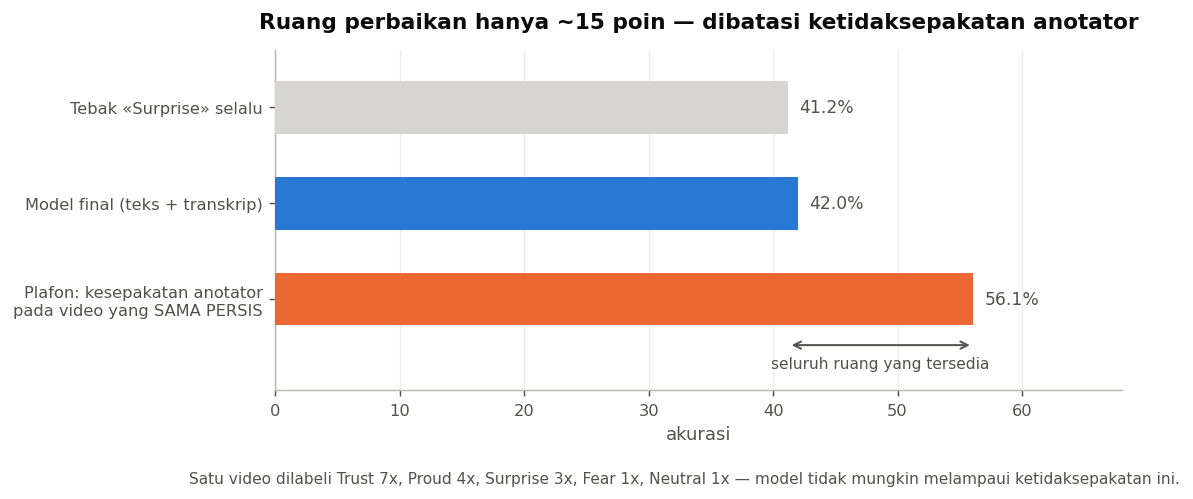

baseline     : 41.2%
model final  : 42.0%
plafon derau : 56.1%

ruang yang benar-benar tersedia: 14.9 poin, bukan 58.8 poin
porsi yang berhasil diambil    : 5%


In [25]:
display(Image("outputs/figures/06_plafon_derau_label.png"))

baseline = 41.2
model = ab.accuracy.iloc[-2] * 100      # teks saja, bobot^0.5
plafon = setuju / baris * 100
print(f"baseline     : {baseline:.1f}%")
print(f"model final  : {model:.1f}%")
print(f"plafon derau : {plafon:.1f}%")
print(f"\nruang yang benar-benar tersedia: {plafon - baseline:.1f} poin, bukan {100 - baseline:.1f} poin")
print(f"porsi yang berhasil diambil    : {(model - baseline) / (plafon - baseline) * 100:.0f}%")

Menyadari batas ini mengubah prioritas proyek. Mengejar akurasi lebih jauh
memberi hasil yang jauh lebih kecil daripada memperkuat interpretasi,
reproduktibilitas, dan penyajian — apalagi karena akurasi hanya 1 dari 7
kriteria penilaian.

---
# Bagian 9 — Prediksi akhir & pasca-pemrosesan

Tiga lapis keputusan, dari yang paling dipercaya ke yang paling tidak:

1. **Jawaban pasti dari duplikat.** Sembilan baris uji URL-nya identik dengan
   baris latih berlabel konsisten. Itu bukan tebakan, itu fakta.
2. **Modus dari video yang sama.** Empat baris uji menunjuk video yang di data
   latih berlabel beragam; dipakai modusnya.
3. **Prediksi model**, dengan mundur ke kelas prior bila baris itu tidak punya
   sinyal sama sekali.

Seluruh penimpaan dicatat ke `outputs/post_processing.csv` — dipertanggungjawabkan,
bukan disembunyikan.

In [26]:
import predict
predict.main()

model final: TF-IDF(text_combined) + LogReg, bobot^0.5
cakupan teks pada train: 88.3%
melatih pada 803 baris...



submission: C:\Users\LENOVO\OneDrive\Documents\BDC\BDC_Tel-U_2026\outputs\submission.csv  (200 baris)
penimpaan pasca-model: 2 baris -> C:\Users\LENOVO\OneDrive\Documents\BDC\BDC_Tel-U_2026\outputs\post_processing.csv

distribusi prediksi test:
emotion
Surprise    162
Trust        24
Proud        12
Joy           1
Fear          1

distribusi label train (pembanding):
emotion
Surprise    331
Trust       183
Proud       156
Joy          53
Anger        36
Sad          18
Fear         16
Neutral       8
Love          1
Loyalty       1

validasi submission: OK


In [27]:
sub = pd.read_csv("outputs/submission.csv")
pp = pd.read_csv("outputs/post_processing.csv")
print(f"submission: {sub.shape}, kolom {list(sub.columns)}")
print()
print(sub.emotion.value_counts().to_string())
print()
print(f"penimpaan pasca-model: {len(pp)} baris")
if len(pp):
    print(pp.to_string(index=False))

submission: (200, 2), kolom ['id', 'emotion']

emotion
Surprise    162
Trust        24
Proud        12
Joy           1
Fear          1

penimpaan pasca-model: 2 baris
 id     dari  jadi                                    alasan
165 Surprise Trust URL identik dengan train, label konsisten
170 Surprise Trust URL identik dengan train, label konsisten


---
# Bagian 10 — Ringkasan

membuat grafik ke C:\Users\LENOVO\OneDrive\Documents\BDC\BDC_Tel-U_2026\outputs\figures ...


  + 01_distribusi_label.png


  + 02_cakupan_data.png


  + 03_kata_pembeda.png


  + 04_ablation.png


  + 05_confusion_matrix.png
  + 06_plafon_derau_label.png
selesai.


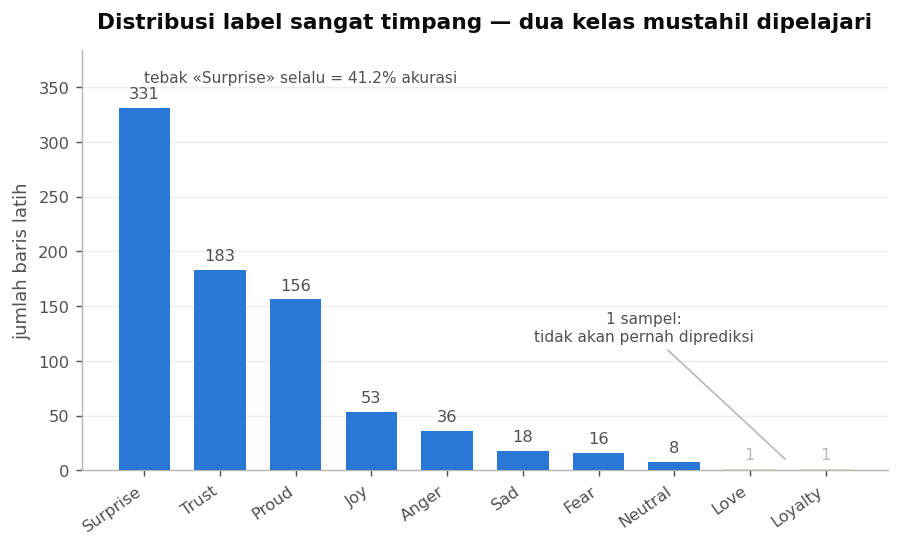

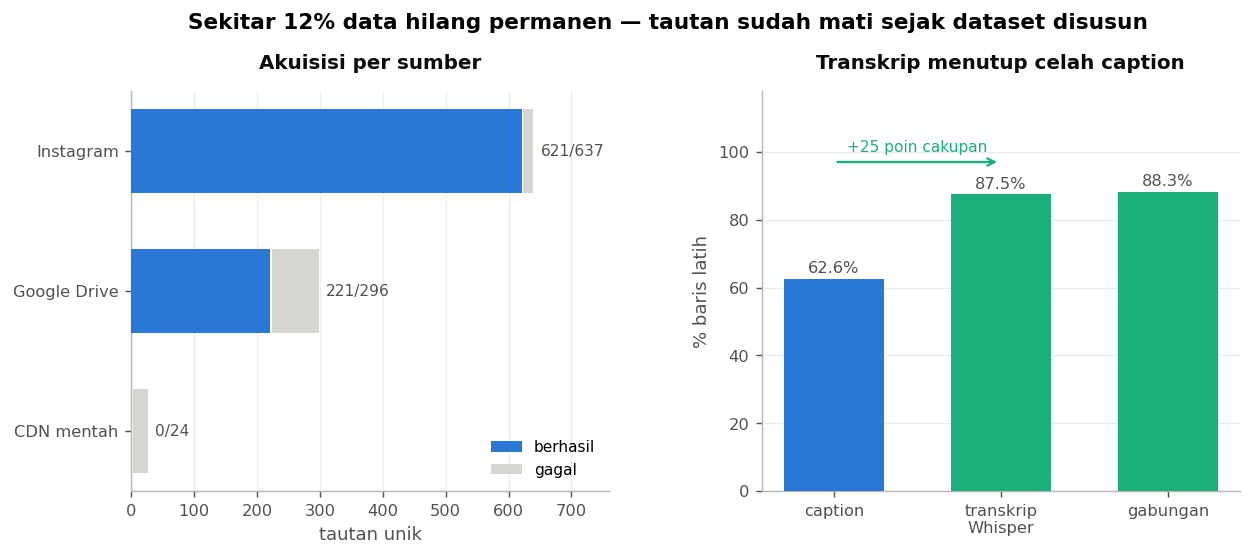

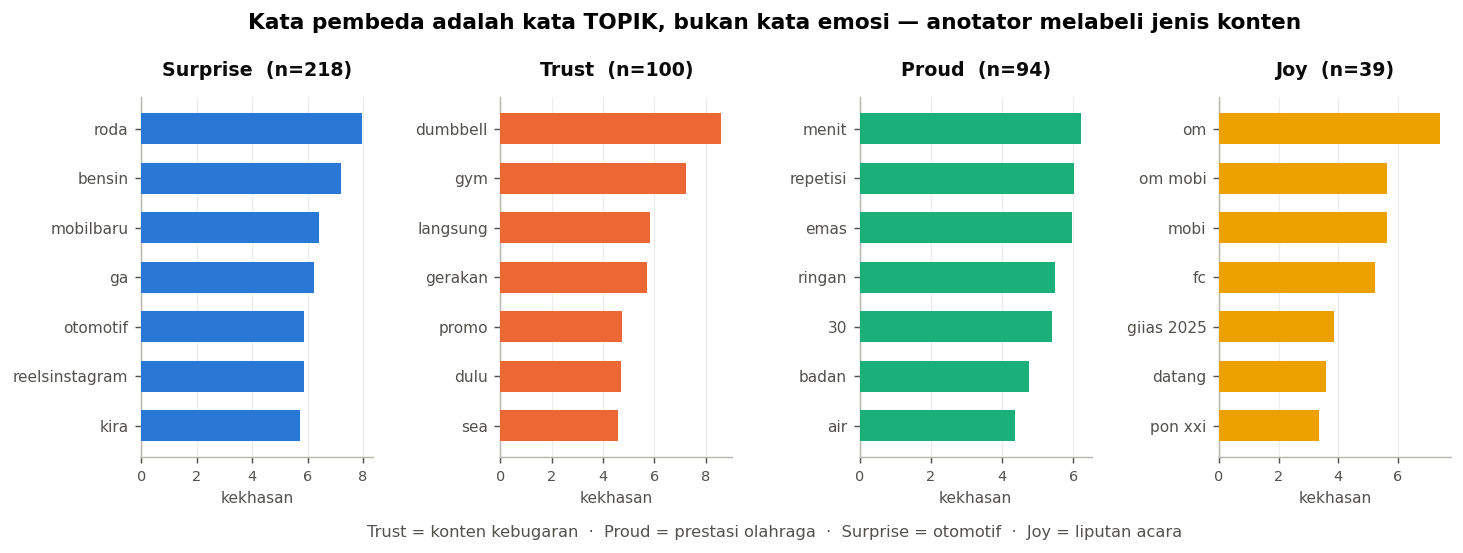

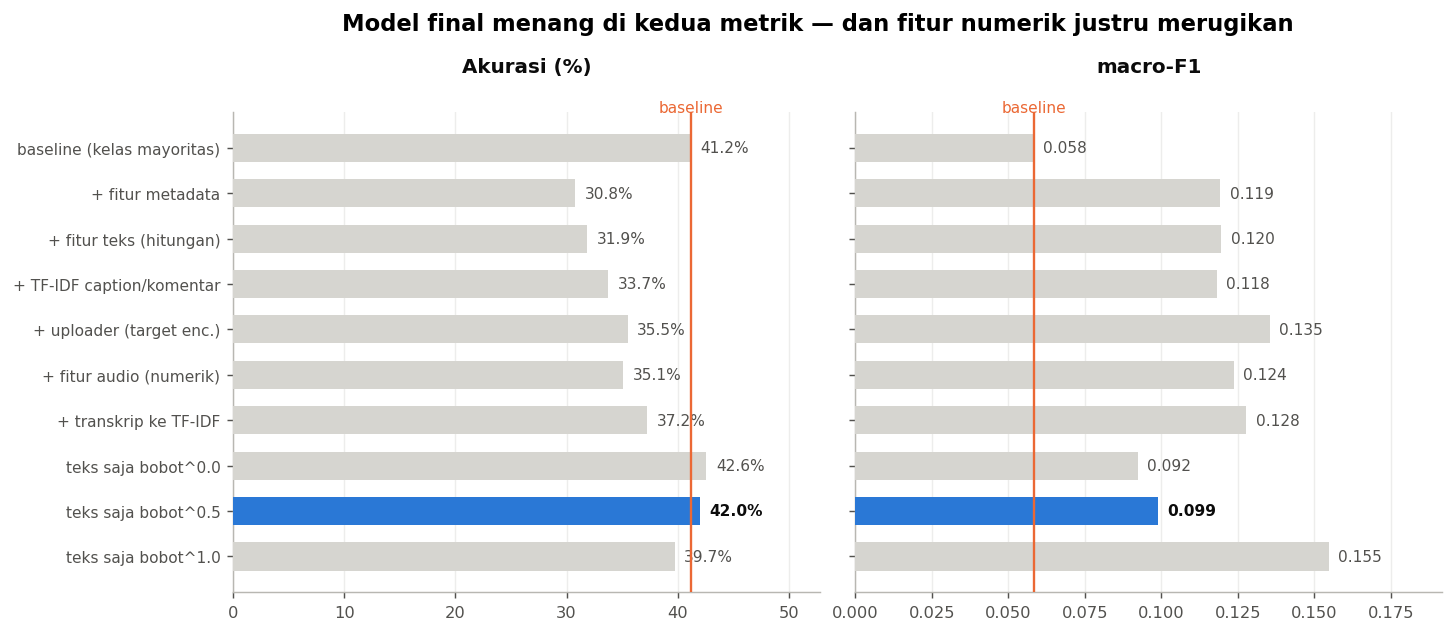

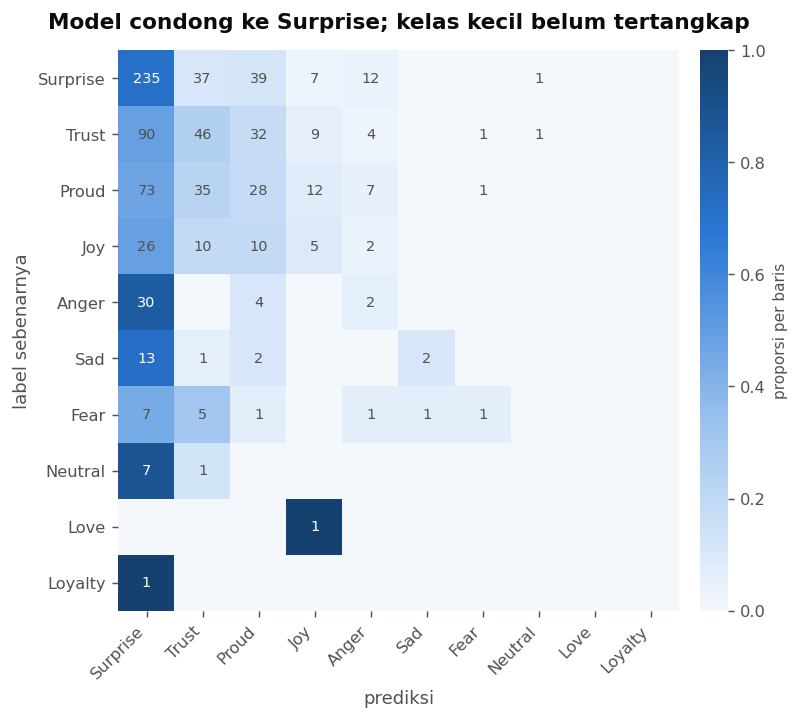

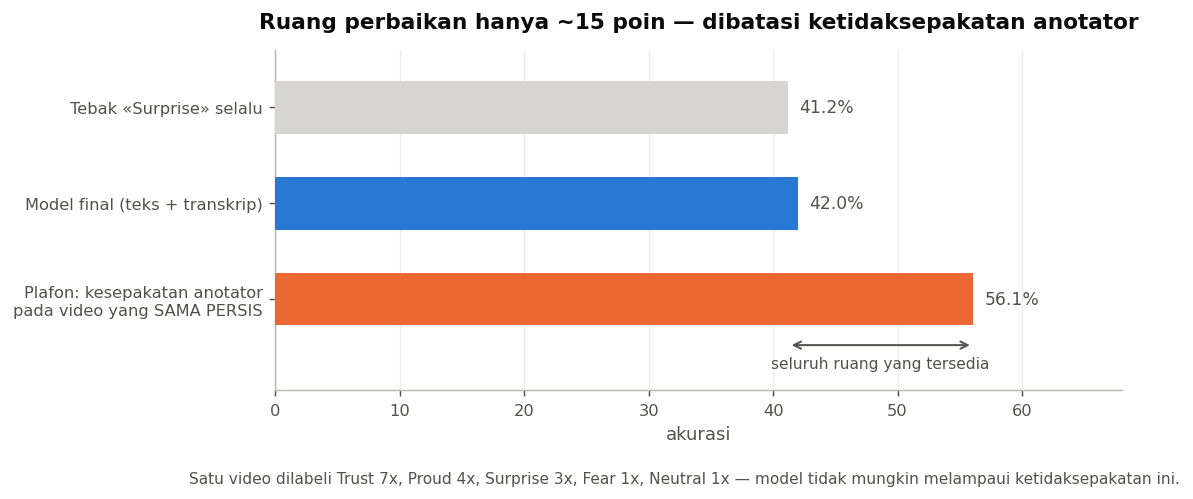

In [28]:
import viz
viz.main()
for f in sorted(pathlib.Path("outputs/figures").glob("*.png")):
    display(Image(str(f)))

## Temuan dan konsekuensinya

| Temuan | Konsekuensi terhadap keputusan |
|---|---|
| Label melacak topik, bukan kata emosi | leksikon dibuang; TF-IDF jadi tulang punggung |
| Fitur numerik menurunkan skor | model final hanya memakai teks |
| Transkrip menambah 25 poin cakupan | konfigurasi pertama yang melewati baseline |
| Anotator hanya sepakat 56% | ruang perbaikan sempit; prioritas dialihkan ke penyajian |
| Heuristik uploader 50,3% ternyata bocor | setiap heuristik wajib divalidasi silang |

## Model final

**TF-IDF (caption + transkrip) → Logistic Regression**, pembobotan kelas
`alpha = 0,5`.

| Metrik | Baseline | Model | Plafon |
|---|---|---|---|
| Akurasi | 41,2% | **42,0%** | ~56% |
| macro-F1 | 0,058 | **0,099** | — |

Mengalahkan baseline pada **kedua** metrik sekaligus.

## Keterbatasan yang perlu dinyatakan terbuka

1. **Data hilang.** 94 dari 803 baris latih (11,7%) dan 25 dari 200 baris uji
   (12,5%) tidak bisa diambil kontennya karena tautannya sudah mati. Baris uji
   tanpa sinyal diprediksi memakai kelas prior.
2. **Dua kelas mustahil dipelajari.** `Love` dan `Loyalty` masing-masing hanya
   punya satu sampel; model tidak akan pernah memprediksinya.
3. **Derau label.** Plafon ~56% diperkirakan dari 41 baris saja, jadi
   perlakukan sebagai indikasi kasar, bukan angka presisi.
4. **Fitur visual belum dieksplorasi.** Prioritasnya rendah karena fitur numerik
   sudah terbukti merugikan pada dataset ini, tapi belum diuji langsung.

## Menjalankan ulang seluruhnya

```bash
python run_all.py     # ±3,5 menit, tanpa internet, tanpa GPU
```

Rincian lengkap keputusan dan jalan buntu yang sempat ditempuh ada di
`RENCANA.md`.